In [1]:
# Bibliothèques Standards
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              mean_gamma_deviance, r2_score)

import statsmodels.api as sm

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

sns.set_theme(style="whitegrid", palette="bright")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

c:\Users\kabir\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Autres
import pyreadr

## Paramètres du projet

In [3]:
# Garantie étudiée
target_freq = "Damage"

# Variable de sévérité
target_sev = "Payment"

# Correspondance garantie / prime
mapping_prime = {"Damage": "PremDamAll",
                 "Fire": "PremFire",
                 "Other": "PremLegal",
                 "Theft": "PremTheft",
                 "TPL": "PremiumTPLV",
                 "Windscreen": "PremWindscreen"
}

target_prem = mapping_prime[target_freq]

print("-"*35)
print("PARAMÈTRES DU MODÈLE")
print("-"*35)

print(f"Garantie étudiée       : {target_freq}")
print(f"Variable sévérité      : {target_sev}")
print(f"Variable prime         : {target_prem}")

-----------------------------------
PARAMÈTRES DU MODÈLE
-----------------------------------
Garantie étudiée       : Damage
Variable sévérité      : Payment
Variable prime         : PremDamAll


## 1. Chargement des données

In [4]:
path_sev = r"C:\Users\kabir\OneDrive\Documents\master CNAM\Projets\Coûts sinistres\\severite.rda"
path_prem = r"C:\Users\kabir\OneDrive\Documents\master CNAM\Projets\Coûts sinistres\\premium.rda"

def read_rda(path):
    """
    Lit un fichier .rda et retourne automatiquement le premier DataFrame.
    """

    result = pyreadr.read_r(path)
    print("Objets trouvés :", list(result.keys()))

    # Récupére le premier objet
    df = next(iter(result.values()))

    return df

df_sev = read_rda(path_sev)
df_prem = read_rda(path_prem)

Objets trouvés : ['fremotor1sev0304a']
Objets trouvés : ['fremotor1prem0304a']


In [5]:
display(" Table Severité ", df_sev.head(3))
display(" Table Primes ", df_prem.head(3))

' Table Severité '

,IDpol,OccurDate,Payment,IDclaim,Guarantee
0,70100084.100a,2003-01-01,104,7201,Windscreen
1,80100041.10b,2003-01-01,628,6995,TPL
2,90105222.100a,2003-01-01,468,6876,TPL


' Table Primes '

,IDpol,Year,DrivAge,DrivGender,MaritalStatus,BonusMalus,LicenceNb,PayFreq,JobCode,VehAge,VehClass,VehPower,VehGas,VehUsage,Garage,Area,Region,Channel,Marketing,PremWindscreen,PremDamAll,PremFire,PremAcc1,PremAcc2,PremLegal,PremTPLM,PremTPLV,PremServ,PremTheft,PremTot
0,1000111.100a,2003.0,44.0,F,Cohabiting,50.0,3.0,Half-yearly,Private employee,10.0,Cheaper,P10,Regular,Private+trip to office,Closed zbox,A2,Headquarters,A,M1,15.0,0.0,0.0,0.0,0.0,6.0,69.1,4.0,50.0,0.0,144.1
1,1000113.100a,2003.0,26.0,F,Cohabiting,85.0,2.0,Annual,Other,8.0,Cheapest,P8,Regular,Private+trip to office,Opened collective parking,A7,Headquarters,A,M2,16.0,0.0,0.0,0.0,0.0,7.0,139.3,7.0,46.0,0.0,215.3
2,1000113.100b,2003.0,26.0,F,Cohabiting,106.0,2.0,Half-yearly,Other,9.0,Cheapest,P8,Regular,Private+trip to office,Opened collective parking,A7,Headquarters,A,M2,34.0,0.0,0.0,0.0,0.0,11.0,283.0,15.0,57.0,0.0,400.0


In [6]:
# Contrôle qualité des données 
def quality_report(df, name):
    
    print("\n" + "-"*35)
    print(f"  RAPPORT SYNTHÉTIQUE : {name}")
    print("-"*35)

    print(f"Nombre de lignes    : {df.shape[0]:,}")
    print(f"Nombre de colonnes  : {df.shape[1]}")

    print(f"Doublons : {df.duplicated().sum()}")

    print("Valeurs manquantes :")
    na = (df.isna()
          .sum()
          .loc[lambda x: x > 0]
          .sort_values(ascending=False)
    )

    if len(na) == 0:
        print("Aucune valeur manquante")
    else:
        display(pd.DataFrame({"Nb NA": na,
                              "%": (100 * na / len(df)).round(2)
            })
        )

    #print("\nTypes des variables")
    #display(df.dtypes.to_frame("Type"))

In [7]:
quality_report(df_sev, "Sévérité")
quality_report(df_prem, "Primes")


-----------------------------------
  RAPPORT SYNTHÉTIQUE : Sévérité
-----------------------------------
Nombre de lignes    : 9,246
Nombre de colonnes  : 5
Doublons : 0
Valeurs manquantes :
Aucune valeur manquante

-----------------------------------
  RAPPORT SYNTHÉTIQUE : Primes
-----------------------------------
Nombre de lignes    : 51,949
Nombre de colonnes  : 30
Doublons : 0
Valeurs manquantes :


,Nb NA,%
MaritalStatus,34948,67.27
JobCode,34948,67.27


## 2. Préparation des données 

In [8]:
# Harmonisation de la granularité des tables 

# Primes : Une ligne par contrat-année .
# Aggrégation des Paiements (Après ca la colonne PayFreq ne sera pas utile + Marital Status peut changer le long du contrat)
# Une ligne, un paiement (et non une échéance : mensuelle, semestrielle, ...)
def granularite_prime(df_prem, vars_tab, target_prem):
    
    agg = {target_prem:"sum"}

    for col in vars_tab:

        if col not in ["IDpol","Year",target_prem, "MaritalStatus"]:
            agg[col]="first"  

        elif col in ["MaritalStatus"]: 
            agg[col] = "last"  #prend en compte la dernière modification

    return (df_prem
            .groupby(["IDpol","Year"],as_index=False)
            .agg(agg)
    )


# Sévérité : 1 ligne un sinistre déclaré (et parfois plusieurs sinistres sur un seul contrat)

In [9]:
vars_prem = df_prem.columns.to_list()

df_prem = granularite_prime(df_prem,
                            vars_prem,
                            target_prem)

In [10]:
# Harminisation des Types + Nettoyage
def preparation_donnees(df):
    
    df = df.copy()

    """
    Harmoniser les types des variables communes.
    """
    # Clés de jointure
    df["IDpol"] = df["IDpol"].astype(str)

    if "Year" in df.columns:
        df["Year"] = df["Year"].astype("Int64")


    """
    Remplacer les valeurs manquantes des variables qualitatives.
    """
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in categorical_cols:

        if col not in df.columns:
            continue

        df[col] = df[col].astype("string")
        df[col] = df[col].fillna("Information manquante")


    """ 
    Convertion des variables numériques
    """
    numeric_cols = df.select_dtypes(include=["number", "float"]).columns.tolist()

    for col in numeric_cols:

        if col in df.columns:
            df[col] = pd.to_numeric(df[col],
                                    errors="coerce"
            )
    
    return df

In [11]:
def data_dictionary(df):
    
    summary = pd.DataFrame({"Variable": df.columns,
                            "Type": df.dtypes.astype(str),
                            "Valeurs manquantes": df.isna().sum(),
                            "% Manquantes": (100 * df.isna().mean()).round(2),
                            "Modalités": [df[col].nunique(dropna=True)
                                          for col in df.columns
                            ]
    })

    return summary.sort_values("Type")

In [12]:
df_sev = preparation_donnees(df_sev)
df_prem = preparation_donnees(df_prem)

print("\n Dictionnaire de la table de sévérité : \n", data_dictionary(df_sev))
print("\n Dictionnaire de la table de primes : \n", data_dictionary(df_prem))


 Dictionnaire de la table de sévérité : 
             Variable    Type  Valeurs manquantes  % Manquantes  Modalités
Payment      Payment   int32                   0           0.0       2250
IDpol          IDpol  string                   0           0.0       6810
OccurDate  OccurDate  string                   0           0.0        722
IDclaim      IDclaim  string                   0           0.0       8968
Guarantee  Guarantee  string                   0           0.0          6

 Dictionnaire de la table de primes : 
                       Variable     Type  ...  % Manquantes  Modalités
Year                      Year    Int64  ...           0.0          2
PremTot                PremTot  float64  ...           0.0       9140
PremWindscreen  PremWindscreen  float64  ...           0.0        177
PremTheft            PremTheft  float64  ...           0.0        377
PremFire              PremFire  float64  ...           0.0         49
PremAcc1              PremAcc1  float64  ...        

In [13]:
# Jointure des tables 
def severity_dataset(df_prem,
                     df_sev,
                     explanatory_vars,
                     guarantee="Damage",
                     target="Payment"):
    """
    Construction de la base de sévérité :
    Une ligne = un sinistre.
    """

    # Préparation de la table des sinistres
    sev = df_sev.copy()

    sev["Year"] = (pd.to_datetime(sev["OccurDate"], errors="coerce").dt.year)
    sev = sev[sev["Guarantee"] == guarantee]
    sev = sev[["IDclaim", "IDpol",
               "Year", target]
    ]

    # Jointure
    df = df_prem.merge(sev,
                       on=["IDpol", "Year"],
                       how="inner",
                       validate="one_to_many"
    )

    df = df[df[target] > 0]
    df = df[explanatory_vars + ["IDclaim", "Year", "IDpol", target]]

    return df

In [14]:
# Variables explicatives 
features = ["DrivAge", "DrivGender", "MaritalStatus", "BonusMalus", "LicenceNb", "PayFreq", "JobCode", 
            "VehAge", "VehClass", "VehPower", "VehGas", "VehUsage", "Garage", "Area", "Region", "Channel",
            "Marketing"
]

In [15]:
df_sev_merge = severity_dataset(df_prem=df_prem,
                                df_sev=df_sev,
                                explanatory_vars=features,
                                guarantee=target_freq,
                                target=target_sev
)


display(df_sev_merge.head(2))

,DrivAge,DrivGender,MaritalStatus,BonusMalus,LicenceNb,PayFreq,JobCode,VehAge,VehClass,VehPower,VehGas,VehUsage,Garage,Area,Region,Channel,Marketing,IDclaim,Year,IDpol,Payment
0,47.0,F,Cohabiting,50.0,4.0,Half-yearly,Private employee,6.0,Medium,P15,Diesel,Private+trip to office,Closed zbox,A5,Headquarters,A,M1,207662,2003,1001951.100b,4683
1,47.0,F,Cohabiting,50.0,4.0,Half-yearly,Private employee,6.0,Medium,P15,Diesel,Private+trip to office,Closed zbox,A5,Headquarters,A,M1,1207662,2004,1001951.100b,4777


In [16]:
quality_report(df_sev_merge, "Sévérité Merged")


-----------------------------------
  RAPPORT SYNTHÉTIQUE : Sévérité Merged
-----------------------------------
Nombre de lignes    : 729
Nombre de colonnes  : 21
Doublons : 0
Valeurs manquantes :
Aucune valeur manquante


In [17]:
df_sev_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729 entries, 0 to 789
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DrivAge        729 non-null    float64
 1   DrivGender     729 non-null    string 
 2   MaritalStatus  729 non-null    string 
 3   BonusMalus     729 non-null    float64
 4   LicenceNb      729 non-null    float64
 5   PayFreq        729 non-null    string 
 6   JobCode        729 non-null    string 
 7   VehAge         729 non-null    float64
 8   VehClass       729 non-null    string 
 9   VehPower       729 non-null    string 
 10  VehGas         729 non-null    string 
 11  VehUsage       729 non-null    string 
 12  Garage         729 non-null    string 
 13  Area           729 non-null    string 
 14  Region         729 non-null    string 
 15  Channel        729 non-null    string 
 16  Marketing      729 non-null    string 
 17  IDclaim        729 non-null    string 
 18  Year           

In [18]:
df_sev_merge.describe()

,DrivAge,BonusMalus,LicenceNb,VehAge,Year,Payment
count,729.000000,729.000000,729.000000,729.000000,729.0,729.000000
mean,40.381344,61.484225,1.956104,5.322359,2003.436214,2091.459534
std,11.774669,14.212770,0.681985,3.922891,0.496255,3077.860941
min,20.000000,50.000000,1.000000,0.000000,2003.0,4.000000
25%,32.000000,50.000000,2.000000,2.000000,2003.0,498.000000
50%,39.000000,56.000000,2.000000,5.000000,2003.0,1139.000000
75%,47.000000,68.000000,2.000000,7.000000,2004.0,2328.000000
max,84.000000,112.000000,6.000000,26.000000,2004.0,24728.000000


## 3. Analyse Exploratoire des données - EDA

### 3.1. Préparation des données X, y, cat_vars, num_vars

In [19]:
def prepare_features(df,
                     target, features,
                     subset=None):

    """
        Préparation des variables avant modélisation.
    
        Parameters
        ----------
        df : DataFrame
        target : str
    
        Returns
        -------
        X : Variables explicatives
        y : Variable cible
        num_vars : Variables numériques
        cat_vars : Variables catégorielles
    
    """

    df = df.copy()

    if subset is None:
        subset = []

    # Colonnes utiles
    df = df[features + [target]]

    # Suppression des NA
    df = df.dropna()

    y = df[target]
    X = df.drop(columns=subset + [target], errors="ignore")

    num_vars = X.select_dtypes(include=["number", "float"]).columns.tolist()
    cat_vars = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

    print("-"*30)
    print("Préparation terminée")
    print(f"Observations : {len(df)}")
    print(f"Variables numériques : {len(num_vars)}")
    print(f"Variables catégorielles : {len(cat_vars)}")
    print("-"*30)

    return X, y, num_vars, cat_vars

In [20]:
X, y, num_vars, cat_vars = prepare_features(df_sev_merge, target_sev, 
                                            features, ["Year", "IDpol", "IDclaim"]
)

------------------------------
Préparation terminée
Observations : 729
Variables numériques : 4
Variables catégorielles : 13
------------------------------


### 3.2. Analyses 

#### 3.2.1. Analyse descriptive des coûts

In [21]:
desc = df_sev_merge[target_sev].describe(percentiles=[.5, .75, .9, .95, .99, .995])
print(desc)

cv = df_sev_merge[target_sev].std() / df_sev_merge[target_sev].mean()
print(f"\nCoefficient de variation : {cv:.3f}")
print(f"Asymétrie (skewness) : {df_sev_merge[target_sev].skew():.3f}")


count      729.000000
mean      2091.459534
std       3077.860941
min          4.000000
50%       1139.000000
75%       2328.000000
90%       4656.600000
95%       6982.800000
99%      17241.960000
99.5%    19452.760000
max      24728.000000
Name: Payment, dtype: float64

Coefficient de variation : 1.472
Asymétrie (skewness) : 3.649


#### 3.2.2. Analyse de la description des coûts 

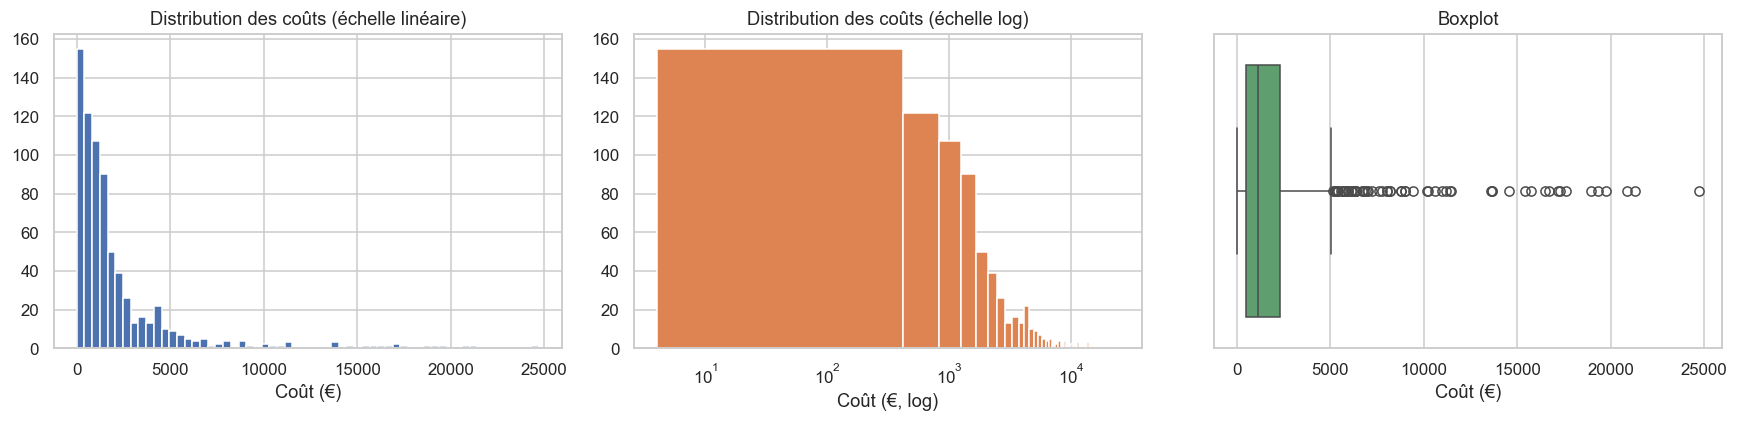

In [22]:
# Distribution des paiements 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_sev_merge[target_sev], bins=60, color="#4C72B0")
axes[0].set_title("Distribution des coûts (échelle linéaire)")
axes[0].set_xlabel("Coût (€)")

axes[1].hist(df_sev_merge[target_sev], bins=60, color="#DD8452")
axes[1].set_xscale("log")
axes[1].set_title("Distribution des coûts (échelle log)")
axes[1].set_xlabel("Coût (€, log)")

sns.boxplot(x=df_sev_merge[target_sev], ax=axes[2], color="#55A868")
axes[2].set_title("Boxplot")
axes[2].set_xlabel("Coût (€)")

plt.tight_layout()
plt.savefig("fig_distribution_couts.png", bbox_inches="tight")
plt.show()

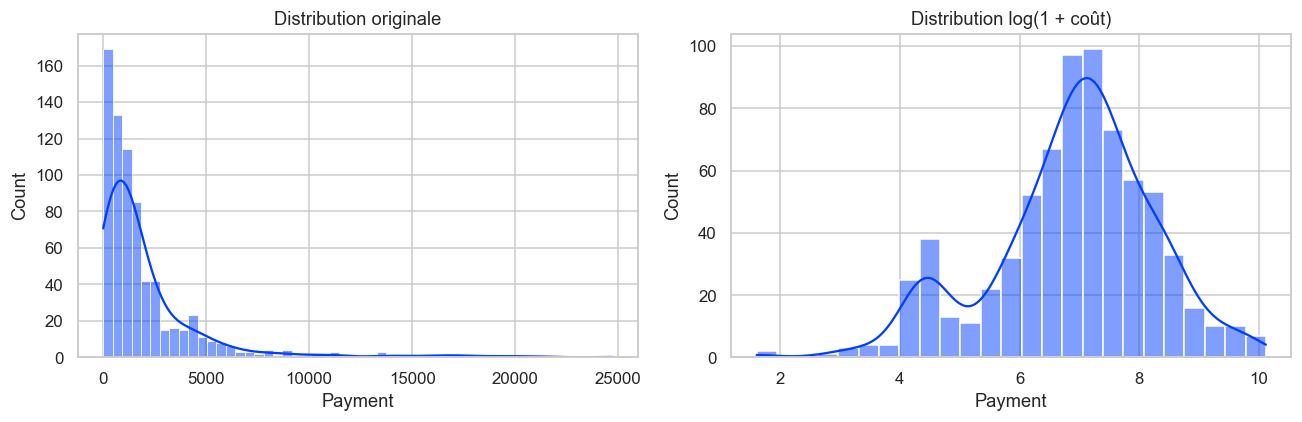

Skewness original : 3.65  |  Skewness log : -0.55


In [23]:
log_cost = np.log1p(df_sev_merge[target_sev])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_sev_merge[target_sev], kde=True, ax=axes[0])
axes[0].set_title("Distribution originale")
sns.histplot(log_cost, kde=True, ax=axes[1])
axes[1].set_title("Distribution log(1 + coût)")
plt.tight_layout()
plt.show()

print(f"Skewness original : {df_sev_merge[target_sev].skew():.2f}  |  Skewness log : {log_cost.skew():.2f}")

#### 3.2.3. Ajustement des distributions statistiques 

Comparaison Gamma / Lognormale / Weibull / Exponentielle par AIC/BIC.
Plus la valeur est faible, meilleur est le compromis ajustement/complexité.

In [24]:
df=df_sev_merge.copy()

In [25]:
def fit_and_score(dist, data, name):
    params = dist.fit(data, floc=0)
    loglik = np.sum(dist.logpdf(data, *params))
    k = len(params)
    n = len(data)
    aic = 2 * k - 2 * loglik
    bic = k * np.log(n) - 2 * loglik
    return {"Distribution": name, "AIC": aic, "BIC": bic, "params": params}

y_temp = df[target_sev].values
distributions = [(stats.gamma, "Gamma"), 
                 (stats.lognorm, "Lognormale"),
                 (stats.weibull_min, "Weibull"), 
                 (stats.expon, "Exponentielle")]

fit_results = [fit_and_score(dist, y_temp, name) for dist, name in distributions]
fit_table = pd.DataFrame(fit_results).sort_values("AIC").reset_index(drop=True)
print(fit_table[["Distribution", "AIC", "BIC"]])
print(f"\nMeilleur ajustement : {fit_table.iloc[0]['Distribution']}")

    Distribution           AIC           BIC
0        Weibull  12556.670354  12570.445376
1     Lognormale  12561.884894  12575.659915
2          Gamma  12578.963472  12592.738493
3  Exponentielle  12609.310231  12618.493579

Meilleur ajustement : Weibull


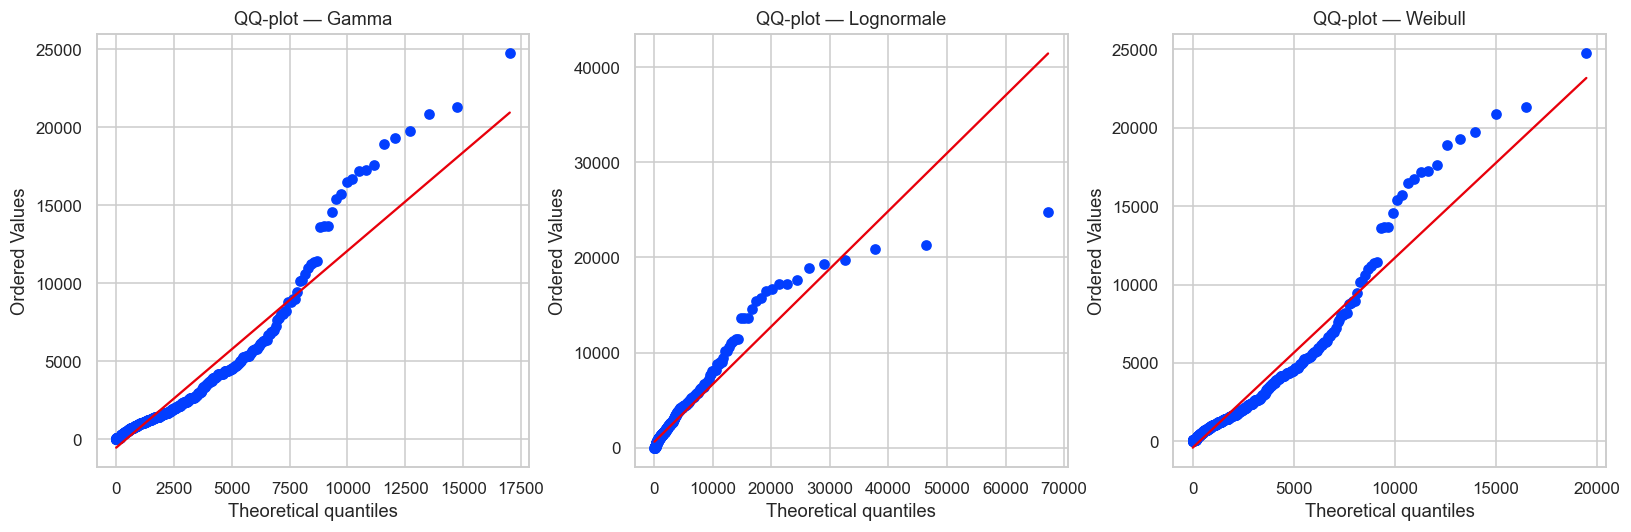

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (dist, name) in zip(axes, [(stats.gamma, "Gamma"), (stats.lognorm, "Lognormale"),
                                     (stats.weibull_min, "Weibull")]):
    params = [r["params"] for r in fit_results if r["Distribution"] == name][0]
    stats.probplot(y_temp, dist=dist, sparams=params, plot=ax)
    ax.set_title(f"QQ-plot — {name}")
plt.tight_layout()
plt.savefig("fig_qqplots.png", bbox_inches="tight")
plt.show()


### 3.2.4. Analyse des facteurs explicatifs 

In [27]:
# Variables numériques 

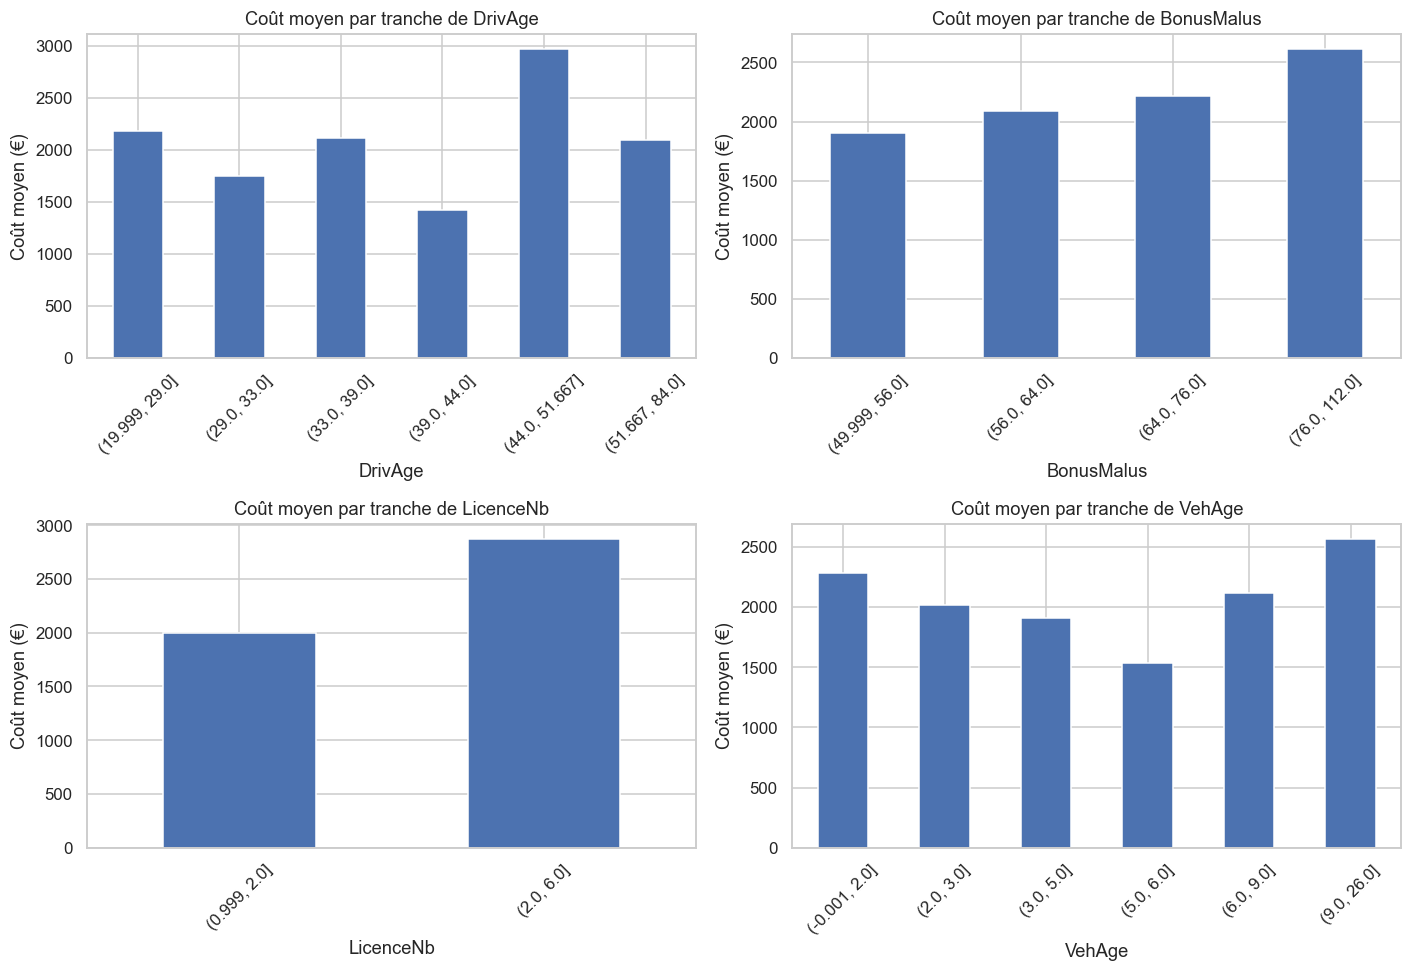

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(num_vars):
    tranche = pd.qcut(df[col], 6, duplicates="drop")
    tab = df.groupby(tranche, observed=True)[target_sev].mean()
    tab.plot(kind="bar", ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Coût moyen par tranche de {col}")
    axes[i].set_ylabel("Coût moyen (€)")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("fig_cout_vs_numeriques.png", bbox_inches="tight")
plt.show()


In [29]:
# Variables catégorielles 

In [30]:
for col in cat_vars:
    tab = df.groupby(col)[target_sev].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
    print(f"\n--- {col} ---")
    print(tab.round(1))



--- DrivGender ---
            count    mean  median
DrivGender                       
M             487  2167.3  1226.0
F             242  1938.9  1052.5

--- MaritalStatus ---
                       count    mean  median
MaritalStatus                               
Widowed                    8  5181.2  2043.5
Married                   64  2870.3  1247.0
Cohabiting               135  2268.7  1079.0
Single                    32  2049.3  1598.0
Information manquante    488  1900.6  1117.5
Divorced                   2    89.0    89.0

--- PayFreq ---
             count    mean  median
PayFreq                           
Quarterly       50  2670.1  1243.5
Half-yearly    396  2114.6  1263.5
Annual         251  1979.9  1050.0
Monthly         32  1775.5   708.0

--- JobCode ---
                       count    mean  median
JobCode                                     
Retailer                   1  4058.0  4058.0
Craftsman                 10  3348.3  1495.0
Other                     11  3176.5 

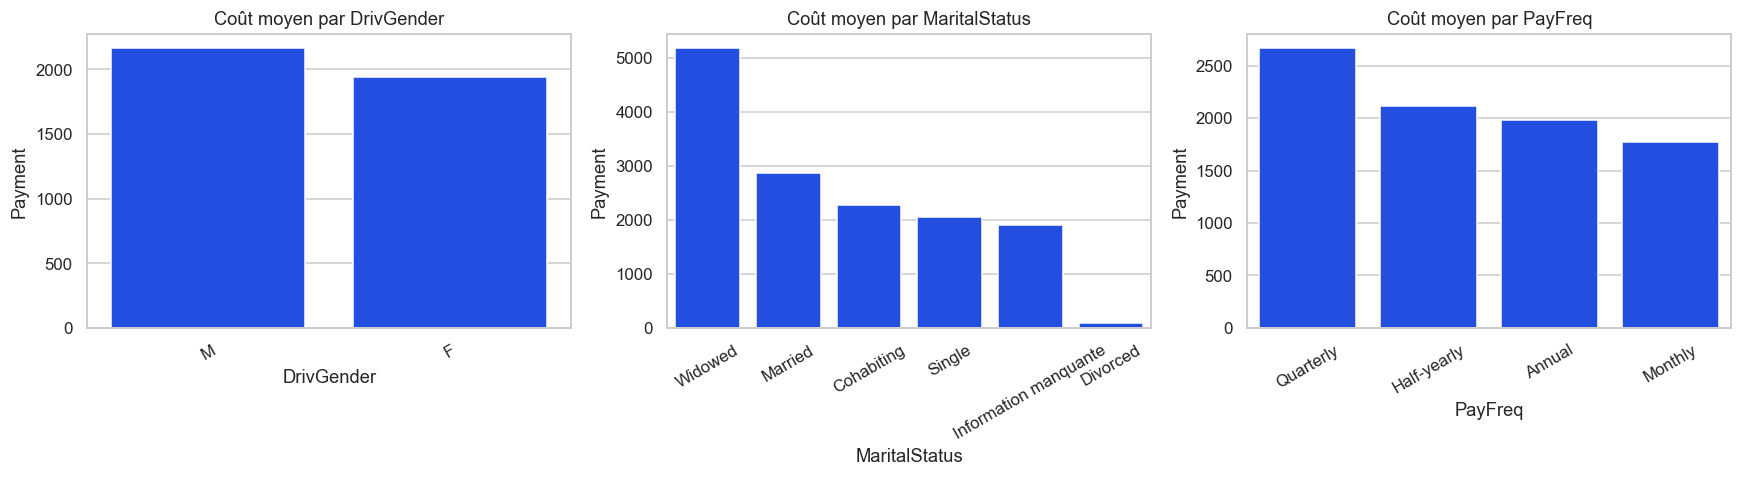

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, cat_vars):
    order = df.groupby(col)[target_sev].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y=target_sev, order=order, ax=ax, estimator="mean", errorbar=None)
    ax.set_title(f"Coût moyen par {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_cout_vs_categorielles.png", bbox_inches="tight")
plt.show()

### 3.2.5. Tests statistiques 

Corrélation de **Spearman** (privilégiée à Pearson : relations potentiellement
non-linéaires, distribution très asymétrique) pour les variables numériques,
et **Kruskal-Wallis** (équivalent non-paramétrique de l'ANOVA, plus adapté
que l'ANOVA classique à des coûts non-gaussiens) pour les catégorielles.

In [32]:
spearman_rows = []
for col in num_vars:
    rho, p = stats.spearmanr(df[col], df[target_sev])
    spearman_rows.append({"Variable": col, "Spearman_rho": rho, "p_value": p})
print(pd.DataFrame(spearman_rows).sort_values("p_value"))


     Variable  Spearman_rho   p_value
2   LicenceNb      0.115874  0.001726
0     DrivAge      0.045889  0.215888
3      VehAge      0.041524  0.262843
1  BonusMalus      0.040925  0.269797


In [33]:
kw_rows = []
for col in cat_vars:
    groups = [df[df[col] == m][target_sev] for m in df[col].unique()]
    H, p = stats.kruskal(*groups)
    kw_rows.append({"Variable": col, "H_statistic": H, "p_value": p})
print(pd.DataFrame(kw_rows).sort_values("p_value"))


         Variable  H_statistic   p_value
5        VehPower    22.893088  0.028647
1   MaritalStatus     8.716546  0.120918
4        VehClass     9.201143  0.238536
3         JobCode     8.983297  0.253858
2         PayFreq     3.696081  0.296207
9            Area     8.102662  0.323628
0      DrivGender     0.535834  0.464164
6          VehGas     0.382893  0.536059
10         Region     1.940288  0.584892
11        Channel     0.953586  0.620771
8          Garage     1.456966  0.692237
12      Marketing     1.456966  0.692237
7        VehUsage     0.708289  0.701774


## 4. Preprocessing

**Attention aux gros sinistres** : contrairement à une variable "bruit" en ML
classique, un sinistre à 15 000€ n'est pas nécessairement une anomalie à
supprimer, c'est potentiellement exactement ce que le modèle doit apprendre
à prédire. On compare donc deux approches plutôt que de trancher a priori.

In [34]:
p99 = df[target_sev].quantile(0.99)
df_winsorized = df.copy()
df_winsorized[target_sev] = df_winsorized[target_sev].clip(upper=p99)

print(f"\nSeuil de winsorisation (P99) : {p99:,.0f} €")
print(f"Nombre d'observations affectées : {(df[target_sev] > p99).sum()} "
      f"({(df[target_sev] > p99).mean():.2%})")

# On fait 2 versions 



Seuil de winsorisation (P99) : 17,242 €
Nombre d'observations affectées : 8 (1.10%)


### 4.1.  Séparation Train / Validation / Test

70% train / 15% validation / 15% test. Pas de dimension temporelle
disponible dans ce jeu simulé — sur des données réelles avec un historique
pluriannuel, un split **temporel** serait préférable (plus réaliste pour un
usage en production : on entraîne sur le passé, on valide sur le futur).

In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

print(f"Train : {len(X_train):,} | Validation : {len(X_val):,} | Test : {len(X_test):,}")

preprocessor = ColumnTransformer([("num", "passthrough", num_vars),
                                  ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_vars),
])
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

X_train_enc = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names, index=X_train.index)
X_val_enc = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names, index=X_val.index)
X_test_enc = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names, index=X_test.index)

# Table statsmodels (formule) -- garde les variables catégorielles en texte
train_sm = X_train.copy(); train_sm[target_sev] = y_train
test_sm = X_test.copy(); test_sm[target_sev] = y_test


Train : 510 | Validation : 109 | Test : 110


### 4.2. Modèle 1 — Référence naïve (baseline)

Prédit systématiquement le coût moyen du train. Tout modèle qui ne bat pas
cette référence n'apporte aucune valeur.

In [36]:
y_pred_baseline = np.repeat(y_train.mean(), len(y_test))
print(f"Coût moyen prédit (constant) : {y_train.mean():,.2f} €")

Coût moyen prédit (constant) : 2,121.65 €


### 4.3. Model 2 - GLM Gamma

In [37]:
X_train_glm = sm.add_constant(X_train_enc, has_constant="add")

model_gamma = sm.GLM(y_train,
                     X_train_glm,
                     family=sm.families.Gamma(link=sm.families.links.Log())).fit()

print(model_gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Payment   No. Observations:                  510
Model:                            GLM   Df Residuals:                      453
Model Family:                   Gamma   Df Model:                           56
Link Function:                    Log   Scale:                          1.4539
Method:                          IRLS   Log-Likelihood:                -4368.7
Date:                Mon, 10 Aug 2026   Deviance:                       638.62
Time:                        16:39:16   Pearson chi2:                     659.
No. Iterations:                   100   Pseudo R-squ. (CS):             0.1517
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [38]:
X_test_glm = sm.add_constant(X_test_enc, has_constant="add").reindex(columns=X_train_glm.columns, fill_value=0)
y_pred_glm = model_gamma.predict(X_test_glm)

### 4.4. Model 3 - Régression LogNormal

In [39]:
log_y_train = np.log(y_train)

pipe_lognorm = Pipeline([("pre", preprocessor), ("model", LinearRegression())])
pipe_lognorm.fit(X_train, log_y_train)

log_pred_test = pipe_lognorm.predict(X_test)

# Correction de Duan (smearing) : moyenne empirique de exp(résidus) sur le train
log_pred_train = pipe_lognorm.predict(X_train)
residuals_train = log_y_train - log_pred_train
duan_factor = np.mean(np.exp(residuals_train))

In [40]:
y_pred_lognorm = np.exp(log_pred_test) * duan_factor
print(f"Facteur de correction de Duan : {duan_factor:.4f}")

Facteur de correction de Duan : 1.9571


### 4.5. Model 4 - Random Forest 

In [41]:
pipe_rf = Pipeline([("pre", preprocessor),
                    ("model", RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                                    random_state=RANDOM_STATE, n_jobs=-1)),
])
pipe_rf.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [42]:
y_pred_rf = pipe_rf.predict(X_test)

### 4.6. Model 5 - XG Boost 

In [43]:
pipe_xgb = Pipeline([("pre", preprocessor),
                     ("model", XGBRegressor(objective="reg:gamma", n_estimators=300, max_depth=4,
                                            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                            random_state=RANDOM_STATE, n_jobs=-1)),
])

pipe_xgb.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [44]:
y_pred_xgb = pipe_xgb.predict(X_test)

### 4.7. Comparaison des modèles 

In [45]:
def compute_metrics(y_true, y_pred, name):
    y_pred_safe = np.clip(y_pred, 1e-3, None)
    return {"Modèle": name,
            "MAE (€)": mean_absolute_error(y_true, y_pred),
            "RMSE (€)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "Déviance Gamma": mean_gamma_deviance(y_true, y_pred_safe),
            "R2": r2_score(y_true, y_pred),
    }

rows = [compute_metrics(y_test, y_pred_baseline, "Baseline (moyenne)"),
        compute_metrics(y_test, y_pred_glm, "GLM Gamma"),
        compute_metrics(y_test, y_pred_lognorm, "Lognormale (Duan)"),
        compute_metrics(y_test, y_pred_rf, "Random Forest"),
]
if y_pred_xgb is not None:
    rows.append(compute_metrics(y_test, y_pred_xgb, "XGBoost"))

comparison = pd.DataFrame(rows).sort_values("Déviance Gamma").reset_index(drop=True)
comparison


,Modèle,MAE (€),RMSE (€),Déviance Gamma,R2
0,GLM Gamma,2134.150297,3732.186047,1.650403,-0.110137
1,Lognormale (Duan),2335.138643,4300.732729,1.727522,-0.474127
2,Baseline (moyenne),2044.451586,3542.282831,1.752755,-0.000038
3,Random Forest,1984.136791,3521.932394,1.763472,0.011420
4,XGBoost,1626.197998,3422.626623,3.522120,0.066382


### 4.8. Analyse des résidus 

Modèle retenu pour l'analyse des résidus : GLM Gamma


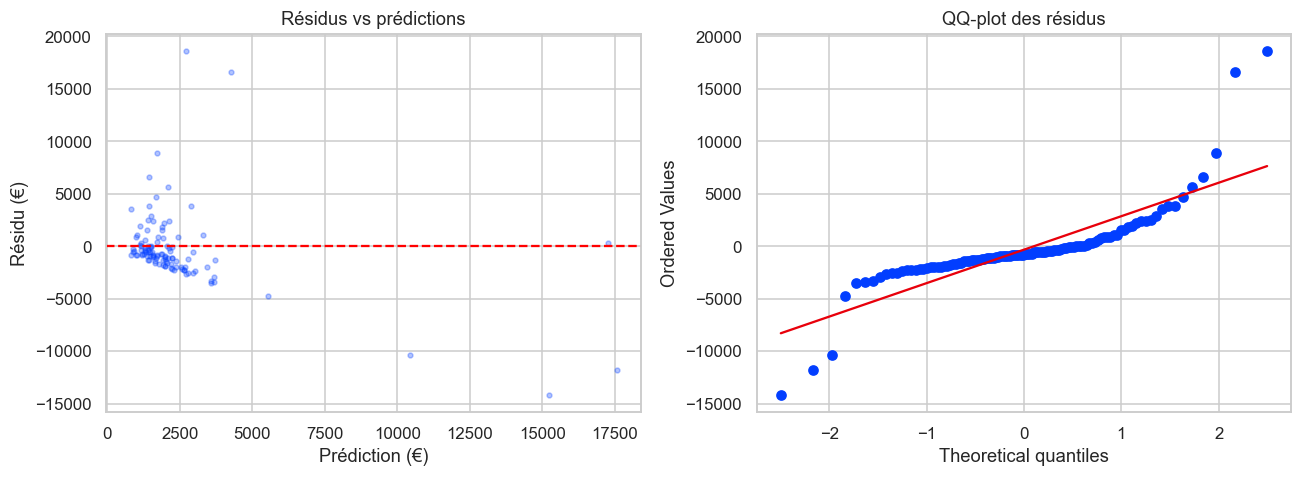

In [46]:
best_model_name = comparison.iloc[0]["Modèle"]
y_pred_by_name = {"Baseline (moyenne)": y_pred_baseline, 
                  "GLM Gamma": y_pred_glm,
                  "Lognormale (Duan)": y_pred_lognorm, 
                  "Random Forest": y_pred_rf,
}

if y_pred_xgb is not None:
   y_pred_by_name["XGBoost"] = y_pred_xgb

y_pred_best = y_pred_by_name[best_model_name]
residuals = y_test.values - y_pred_best
print(f"Modèle retenu pour l'analyse des résidus : {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Prédiction (€)"); axes[0].set_ylabel("Résidu (€)")
axes[0].set_title("Résidus vs prédictions")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot des résidus")
plt.tight_layout()
plt.savefig("fig_residus.png", bbox_inches="tight")
plt.show()


In [47]:
residus_par_quantile = pd.DataFrame({"y_test": y_test.values, "residu": residuals})
residus_par_quantile["quantile_cout"] = pd.qcut(y_test, [0, .5, .75, .9, .95, .99, 1.0],
                                                labels=["P0-P50", "P50-P75", "P75-P90", "P90-P95", "P95-P99", "P99+"], duplicates="drop"
)
print(residus_par_quantile.groupby("quantile_cout", observed=True)["residu"].agg(["mean", "std", "count"]))


                       mean          std  count
quantile_cout                                  
P0-P50         -1717.247872  1513.934772     55
P50-P75         -899.215092  2755.911668     27
P75-P90         1293.727768  1288.874389     17
P90-P95          574.756022  6968.437180      5
P95-P99         5377.574313  3618.329609      4
P99+           17593.870823  1411.065099      2


### 4.9. Performances sur les sinistres coûteux

Un modèle peut avoir un excellent MAE global tout en étant mauvais
précisément là où l'enjeu financier est le plus fort, les gros sinistres.

In [48]:
tail_rows = []
for label, q in [("Tous", 0.0), ("P90+", 0.90), ("P95+", 0.95), ("P99+", 0.99)]:
    seuil = y_test.quantile(q)
    mask = y_test >= seuil
    tail_rows.append({"Segment": label, "N": int(mask.sum()),
                      "MAE (€)": mean_absolute_error(y_test[mask], y_pred_best[mask]),
                      "Coût réel moyen (€)": y_test[mask].mean(),
                      "Coût prédit moyen (€)": y_pred_best[mask].mean(),
    })

pd.DataFrame(tail_rows)

,Segment,N,MAE (€),Coût réel moyen (€),Coût prédit moyen (€)
0,Tous,110,2134.150297,2099.900000,2437.738631
1,P90+,11,7561.018456,10435.181818,5019.561908
2,P95+,6,9449.673149,14364.166667,4914.493517
3,P99+,2,17593.870823,21083.000000,3489.129177


## 5. Interprétation du modèle

### 5.1. GLM Gamma — effets multiplicatifs (`exp(β)`)

Avec un lien log, `exp(β_j)` s'interprète directement comme un facteur
multiplicatif sur le coût attendu : `exp(β)=1.08` équivaut à **+8% de coût attendu**
par unité de la variable, toutes choses égales par ailleurs.

In [49]:
effets = pd.DataFrame({"Variable": model_gamma.params.index,
                       "Coefficient": model_gamma.params.values,
                       "Effet multiplicatif (exp(coef))": np.exp(model_gamma.params.values),
                       "p_value": model_gamma.pvalues.values}).sort_values("p_value")

effets

,Variable,Coefficient,Effet multiplicatif (exp(coef)),p_value
0,const,5.540784,254.877791,4.158374e-23
59,cat__Marketing_M3,1.941570,6.969684,6.569764e-21
43,cat__Garage_Closed zbox,1.868375,6.477760,2.063950e-20
44,cat__Garage_Opened collective parking,0.939464,2.558610,2.085241e-15
58,cat__Marketing_M2,0.939464,2.558610,2.085241e-15
...,...,...,...,...
57,cat__Channel_L,0.018113,1.018278,8.986419e-01
11,cat__PayFreq_Half-yearly,0.016222,1.016354,8.990196e-01
46,cat__Area_A3,0.015661,1.015784,9.340157e-01
39,cat__VehPower_P9,-0.012832,0.987250,9.551877e-01


### 5.2. Random Forest — importance des variables

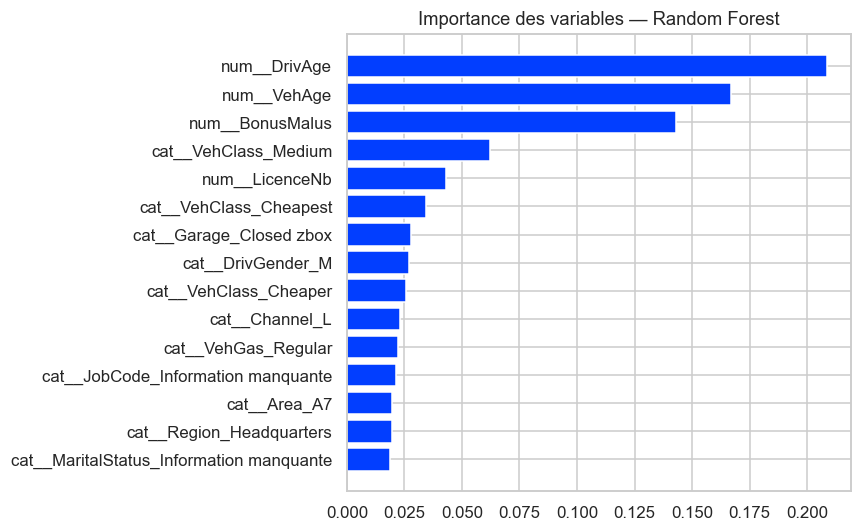

In [50]:
rf_model = pipe_rf.named_steps["model"]
importance_rf = pd.DataFrame({"Variable": feature_names, 
                              "Importance": rf_model.feature_importances_}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_rf["Variable"].head(15)[::-1], importance_rf["Importance"].head(15)[::-1])
plt.title("Importance des variables — Random Forest")
plt.tight_layout()
plt.savefig("fig_importance_rf.png", bbox_inches="tight")
plt.show()


### 5.3. SHAP _ Vue globale 

C:\Users\kabir\AppData\Local\Temp\ipykernel_4432\1186922.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)


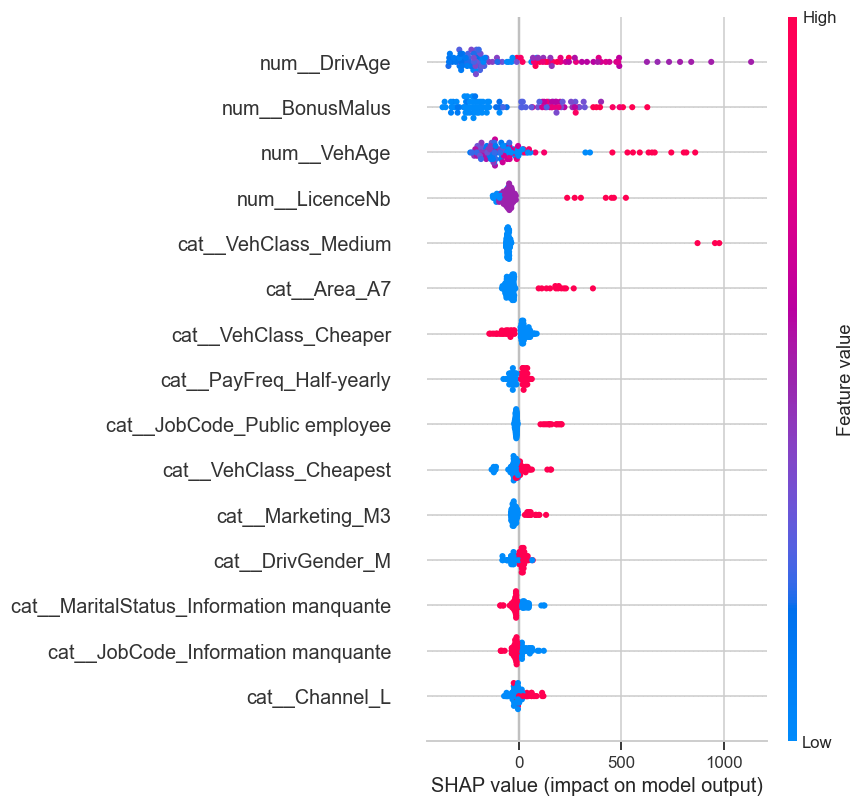

In [51]:
explainer = shap.TreeExplainer(rf_model)
X_test_sample = X_test_enc.sample(min(2000, len(X_test_enc)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_values, X_test_sample, max_display=15, show=False)
plt.savefig("fig_shap_summary.png", bbox_inches="tight")
plt.show()

## 6. Validation actuarielle — réel vs prédit par décile

Vérifie que le modèle **ordonne** correctement les risques, pas seulement
qu'il est précis en moyenne — c'est la propriété recherchée pour la
segmentation tarifaire.

        Cout_reel_moyen  Cout_predit_moyen   N
decile                                        
1                1302.5              967.7  11
2                 951.6             1246.5  11
3                2236.7             1413.1  11
4                1496.1             1542.8  11
5                2637.6             1736.6  11
6                1369.8             1949.4  11
7                1972.2             2124.2  11
8                 893.7             2414.5  11
9                3611.5             2927.6  11
10               4527.2             8055.0  11


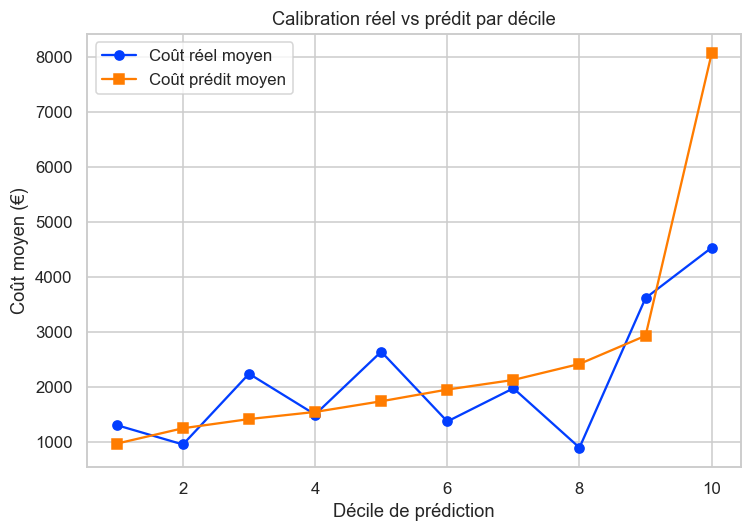

In [52]:
calib = pd.DataFrame({"reel": y_test.values, "predit": y_pred_best})
calib["decile"] = pd.qcut(calib["predit"], 10, labels=False, duplicates="drop") + 1

calib_table = calib.groupby("decile").agg(Cout_reel_moyen=("reel", "mean"), 
                                          Cout_predit_moyen=("predit", "mean"), N=("reel", "size")).round(1)
print(calib_table)

plt.figure(figsize=(7, 5))
plt.plot(calib_table.index, calib_table["Cout_reel_moyen"], marker="o", label="Coût réel moyen")
plt.plot(calib_table.index, calib_table["Cout_predit_moyen"], marker="s", label="Coût prédit moyen")
plt.xlabel("Décile de prédiction"); plt.ylabel("Coût moyen (€)")
plt.title("Calibration réel vs prédit par décile")
plt.legend()
plt.tight_layout()
plt.savefig("fig_calibration_decile.png", bbox_inches="tight")
plt.show()

## 7. Application — prédire le coût d'un nouveau profil

In [53]:
for col in cat_vars:
    print(f"\n--- {col} ({df[col].nunique()} modalités) ---")
    print(df[col].value_counts())


--- DrivGender (2 modalités) ---
DrivGender
M    487
F    242
Name: count, dtype: Int64

--- MaritalStatus (6 modalités) ---
MaritalStatus
Information manquante    488
Cohabiting               135
Married                   64
Single                    32
Widowed                    8
Divorced                   2
Name: count, dtype: Int64

--- PayFreq (4 modalités) ---
PayFreq
Half-yearly    396
Annual         251
Quarterly       50
Monthly         32
Name: count, dtype: Int64

--- JobCode (8 modalités) ---
JobCode
Information manquante    488
Private employee         132
Public employee           70
Retiree                   13
Other                     11
Craftsman                 10
Farmer                     4
Retailer                   1
Name: count, dtype: Int64

--- VehClass (8 modalités) ---
VehClass
Cheaper           220
Cheapest          213
Cheap             128
Medium low         96
Medium             34
Medium high        27
Expensive           6
More expensive      5
Name:

In [54]:
new_client = pd.DataFrame({"DrivAge": [39], "DrivGender" : ["F"], "MaritalStatus" : ["Married"], "BonusMalus" : [83], "LicenceNb" : [2], 
                           "PayFreq" : ["Half-yearly"], "JobCode" : ["Private employee"], "VehAge":[4], "VehClass" : ["Cheaper"], 
                           "VehPower" : ["P11"], "VehGas" : ["Diesel"], "VehUsage" : ["Private+trip to office"], "Garage" : ["Closed zbox"], 
                           "Area" : ["A5"], "Region" : ["Headquarters"], "Channel" : ["A"], "Marketing" : ["M1"]
                           
})

new_client_sm = new_client.copy()
new_client_enc = pd.DataFrame(preprocessor.transform(new_client_sm),
                              columns=feature_names,
                              index=new_client.index
)
new_client_glm = sm.add_constant(new_client_enc, has_constant="add").reindex(columns=X_train_glm.columns, 
                                                                             fill_value=0
)

prediction_glm = np.asarray(model_gamma.predict(new_client_glm))[0]


# Intervalle empirique -- quantiles des ratios (predit/reel) observés sur le test
ratios = y_test.values / np.clip(y_pred_best, 1e-3, None)
p5, p95 = np.quantile(ratios, [0.05, 0.95])

print(f"Coût attendu (GLM Gamma) : {prediction_glm:,.0f} €")
print(f"Intervalle de prédiction empirique (P5-P95) : "
      f"[{prediction_glm*p5:,.0f} € ; {prediction_glm*p95:,.0f} €]")


Coût attendu (GLM Gamma) : 2,282 €
Intervalle de prédiction empirique (P5-P95) : [80 € ; 8,592 €]
